<a href="https://colab.research.google.com/github/ShachiPradhan/CODSOFT_TASKNO_2/blob/main/movierating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
from google.colab import files
uploaded = files.upload()

Saving IMDb Movies India.csv to IMDb Movies India (2).csv


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (15509, 10)

Columns: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Missing values:
 Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

Data types:
 Name         object
Year         object
Duration     object
Genre        object
Rating      float64
Votes        object
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object

First 5 rows:


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [38]:
df = df.dropna(subset=['Rating'])
print("After dropping missing ratings:", df.shape)

After dropping missing ratings: (7919, 10)


In [39]:
df = df.reset_index(drop=True)

In [40]:
df = df[df['Name'].notna() & (df['Name'].str.strip() != '')]

In [41]:
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
print("Year NaNs:", df['Year'].isna().sum())

Year NaNs: 0


In [42]:
df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

In [43]:
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

In [44]:
# Drop rows missing Year (very few)
df = df.dropna(subset=['Year'])

# Fill numerical
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Votes'] = df['Votes'].fillna(0)

# Fill categorical
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = df[col].fillna('Unknown')

print("Final shape:", df.shape)
print(df.isnull().sum())

Final shape: (7919, 10)
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


In [45]:
df = df.drop_duplicates(subset=['Name', 'Year', 'Director'], keep='first')
print("After dedup:", df.shape)

After dedup: (7918, 10)


In [46]:
df = df.reset_index(drop=True)

In [47]:
print("Index is unique:", df.index.is_unique)
print("Duplicates:", df.index.duplicated().sum())

Index is unique: True
Duplicates: 0


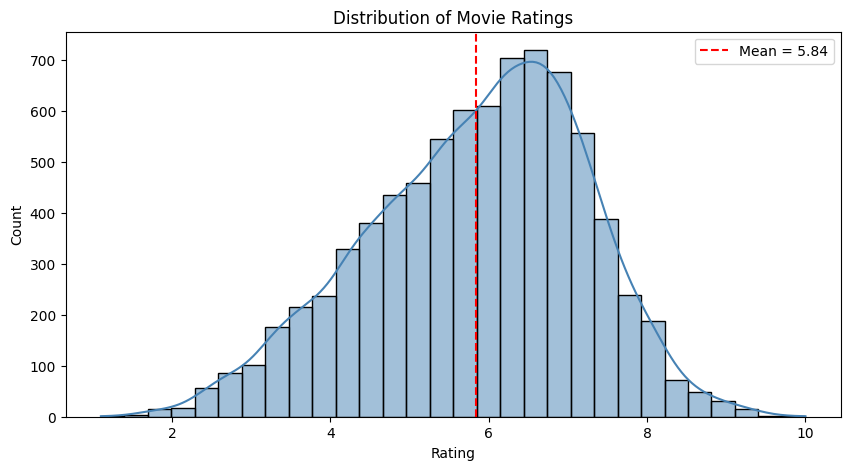

count    7918.000000
mean        5.841336
std         1.381631
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64


In [48]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=30, kde=True, color='steelblue')
plt.axvline(df['Rating'].mean(), color='red', linestyle='--',
            label=f"Mean = {df['Rating'].mean():.2f}")
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.legend()
plt.show()

print(df['Rating'].describe())

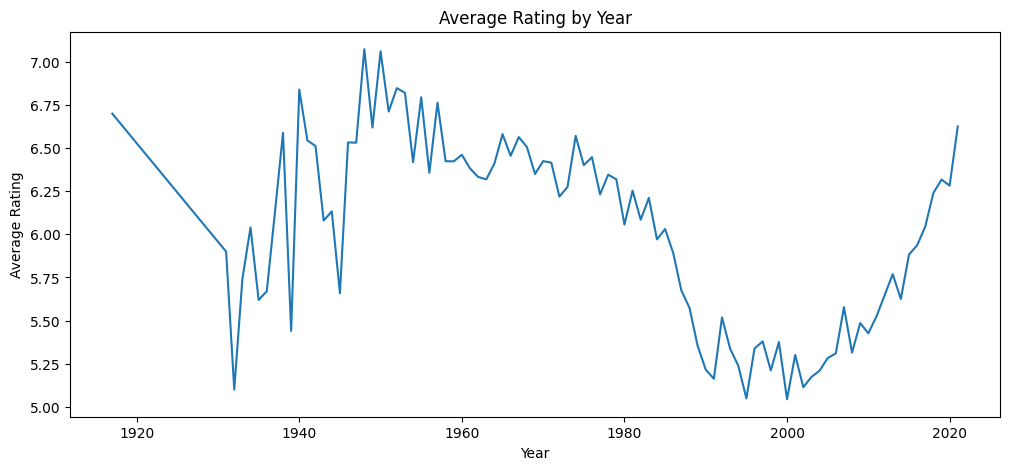

In [49]:
plt.figure(figsize=(12, 5))
df.groupby('Year')['Rating'].mean().plot()
plt.title('Average Rating by Year')
plt.ylabel('Average Rating')
plt.show()

                 mean  count
Genre                       
Documentary  7.613287    143
Biography    6.810638    141
History      6.804688    128
Sport        6.494118     51
Family       6.195173    663
Musical      6.156627    498
Music        6.137705     61
Unknown      5.999020    102
Drama        5.998558   4924
Animation    5.956164     73


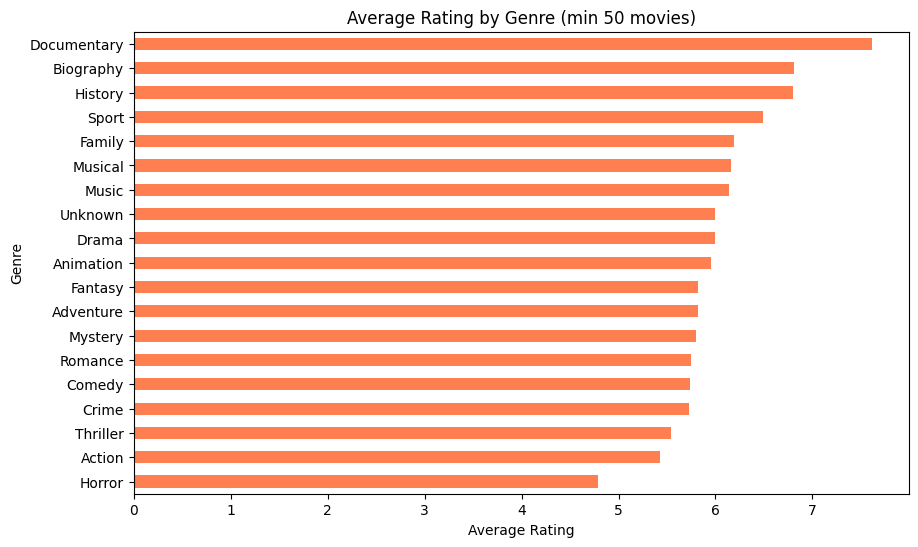

In [51]:
# Work on a copy, not on df directly
genre_stats = (
    df[['Genre', 'Rating']]
      .assign(Genre=df['Genre'].str.split(', '))
      .explode('Genre')                       # ← explode the DataFrame
      .groupby('Genre')['Rating']
      .agg(['mean', 'count'])
      .query('count >= 50')
      .sort_values('mean', ascending=False)
)

print(genre_stats.head(10))
plt.figure(figsize=(10, 6))
genre_stats['mean'].plot(kind='barh', color='coral')
plt.title('Average Rating by Genre (min 50 movies)')
plt.gca().invert_yaxis()
plt.xlabel('Average Rating')
plt.show()

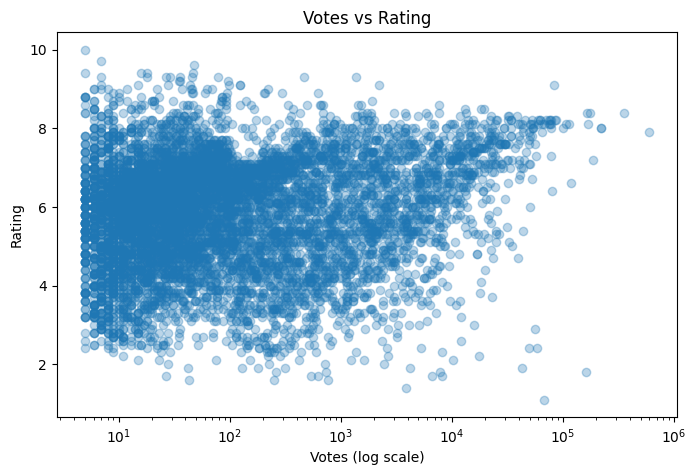

Correlation: 0.12669111788444182


In [52]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Votes'], df['Rating'], alpha=0.3)
plt.xscale('log')
plt.xlabel('Votes (log scale)')
plt.ylabel('Rating')
plt.title('Votes vs Rating')
plt.show()

print("Correlation:", df['Votes'].corr(df['Rating']))

In [53]:
print("Top 10 Directors by count:")
print(df['Director'].value_counts().head(10))

print("\nTop 10 Actors:")
print(pd.concat([df['Actor 1'], df['Actor 2'], df['Actor 3']])
        .value_counts().head(10))

Top 10 Directors by count:
Director
Mahesh Bhatt            47
David Dhawan            43
Hrishikesh Mukherjee    42
Shakti Samanta          39
Kanti Shah              38
Rama Rao Tatineni       34
Ram Gopal Varma         34
Basu Chatterjee         34
Vikram Bhatt            33
Shibu Mitra             33
Name: count, dtype: int64

Top 10 Actors:
Unknown               617
Mithun Chakraborty    231
Dharmendra            217
Jeetendra             179
Ashok Kumar           176
Amitabh Bachchan      163
Rekha                 133
Rajesh Khanna         132
Shashi Kapoor         126
Sanjay Dutt           123
Name: count, dtype: int64


In [54]:
from sklearn.preprocessing import MultiLabelBinarizer

df['Genre_list'] = df['Genre'].str.split(', ')
mlb = MultiLabelBinarizer()
genre_df = pd.DataFrame(
    mlb.fit_transform(df['Genre_list']),
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=df.index
)
print("Genre features:", genre_df.shape)

Genre features: (7918, 23)


In [55]:
for col in ['Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    freq = df[col].value_counts()
    df[f'{col}_freq'] = df[col].map(freq)

In [56]:
df['Movie_Age'] = 2024 - df['Year']
df['Log_Votes'] = np.log1p(df['Votes'])
df['Num_Genres'] = df['Genre_list'].apply(len)
df['Has_Unknown_Director'] = (df['Director'] == 'Unknown').astype(int)

In [57]:
base_features = df[[
    'Year', 'Duration', 'Votes', 'Log_Votes', 'Movie_Age', 'Num_Genres',
    'Has_Unknown_Director',
    'Director_freq', 'Actor 1_freq', 'Actor 2_freq', 'Actor 3_freq'
]]

X = pd.concat([base_features, genre_df], axis=1)
y = df['Rating']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (7918, 34)


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (6334, 34) Test: (1584, 34)


In [59]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'R2': r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(results_df)

                       RMSE       MAE        R2
Gradient Boosting  1.049100  0.791953  0.406058
Random Forest      1.067528  0.800703  0.385008
Ridge              1.181003  0.921232  0.247317
Linear Regression  1.181160  0.921342  0.247116


In [60]:
# pip install xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)

print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("XGBoost MAE:", mean_absolute_error(y_test, preds))
print("XGBoost R2:", r2_score(y_test, preds))

XGBoost RMSE: 1.053777899099326
XGBoost MAE: 0.7885124539486085
XGBoost R2: 0.4007493808963225


In [61]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f"CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV R² scores: [0.40408558 0.42086473 0.41482356 0.40286578 0.36411351]
Mean CV R²: 0.4014 (+/- 0.0198)


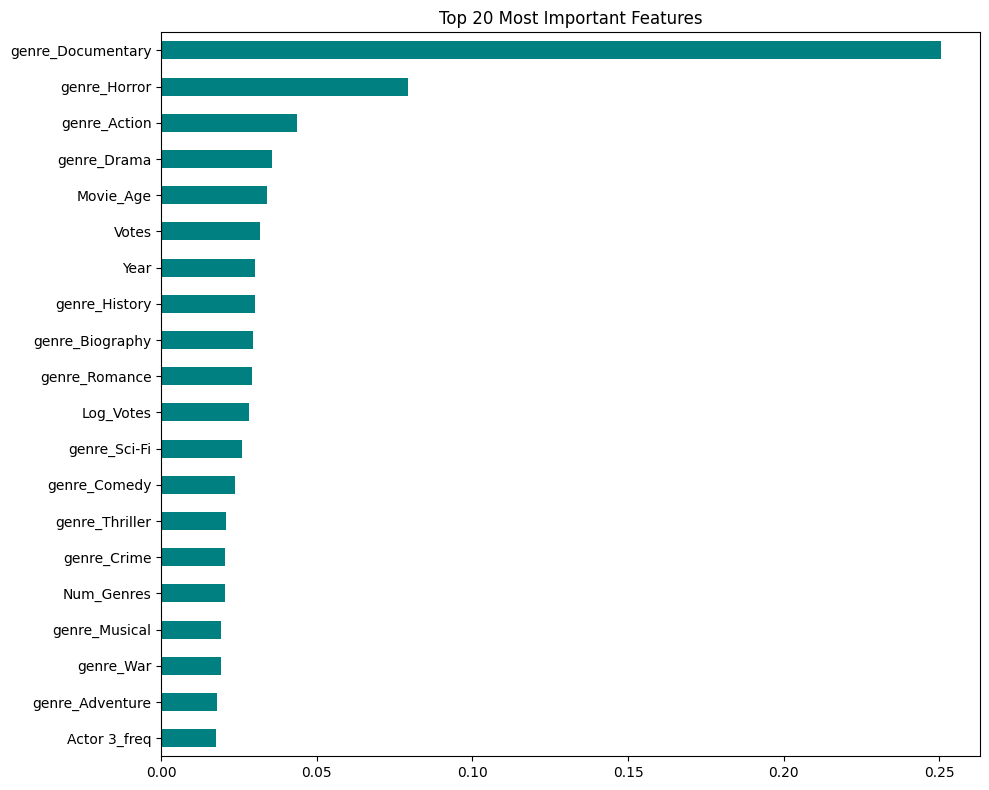

In [62]:
importances = pd.Series(xgb.feature_importances_, index=X.columns) \
                 .sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='teal')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

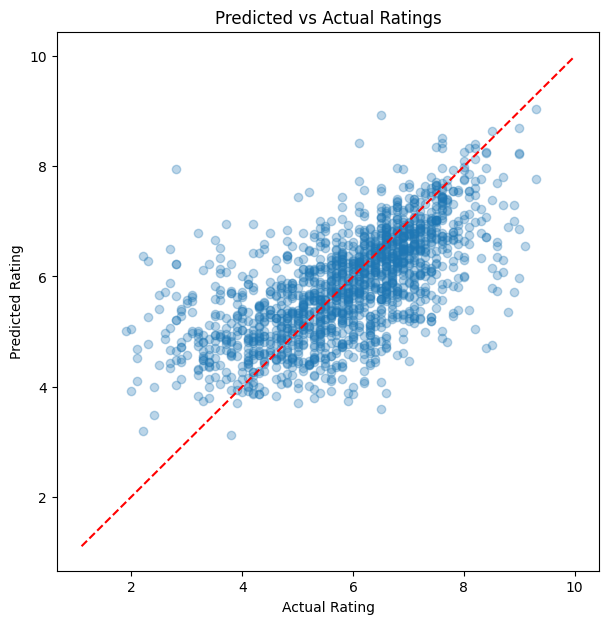

In [63]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Predicted vs Actual Ratings')
plt.show()

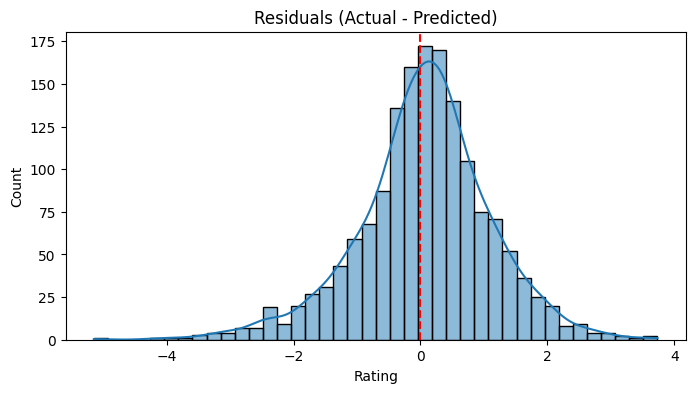

In [64]:
residuals = y_test - preds
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals (Actual - Predicted)')
plt.show()

In [65]:
import joblib
joblib.dump(xgb, 'movie_rating_xgb.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

['feature_columns.pkl']

In [66]:
def predict_rating(year, duration, votes, genres, director_freq,
                   actor1_freq, actor2_freq, actor3_freq):
    row = {
        'Year': year,
        'Duration': duration,
        'Votes': votes,
        'Log_Votes': np.log1p(votes),
        'Movie_Age': 2024 - year,
        'Num_Genres': len(genres),
        'Has_Unknown_Director': 0,
        'Director_freq': director_freq,
        'Actor 1_freq': actor1_freq,
        'Actor 2_freq': actor2_freq,
        'Actor 3_freq': actor3_freq,
    }
    for g in mlb.classes_:
        row[f'genre_{g}'] = 1 if g in genres else 0

    X_new = pd.DataFrame([row])[X.columns]
    return xgb.predict(X_new)[0]

print(predict_rating(2019, 130, 50000, ['Action', 'Drama'],
                     50, 30, 20, 15))

4.6930842
